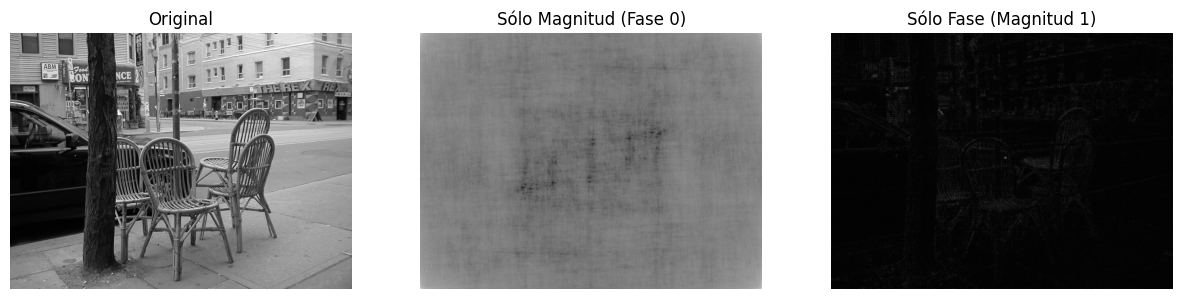

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen (puedes usar 'chairs.jpg' o cualquier otra de tu carpeta)
img = cv2.imread('chairs.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: No se encuentra la imagen.")
else:
    # 1. Calcular la TDF (Transformada Discreta de Fourier)
    f = np.fft.fft2(img)
    
    # 2. Obtener Magnitud y Fase
    magnitud = np.abs(f)
    fase = np.angle(f)
    
    # 3. Reconstrucción SÓLO con Magnitud (Fase = 0)
    # f_mag = magnitud * exp(j * 0) = magnitud
    f_solo_magnitud = magnitud * np.exp(1j * 0)
    img_solo_magnitud = np.abs(np.fft.ifft2(f_solo_magnitud))
    
    # 4. Reconstrucción SÓLO con Fase (Magnitud = 1)
    # f_fase = 1 * exp(j * fase)
    f_solo_fase = np.exp(1j * fase)
    img_solo_fase = np.abs(np.fft.ifft2(f_solo_fase))

    # Visualización
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    # Aplicamos logaritmo a la reconstrucción de magnitud para visualizar mejor la energía
    plt.imshow(np.log(img_solo_magnitud + 1), cmap='gray')
    plt.title('Sólo Magnitud (Fase 0)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(img_solo_fase, cmap='gray')
    plt.title('Sólo Fase (Magnitud 1)')
    plt.axis('off')
    
    plt.show()

### Respuestas al Ejercicio 2: Importancia de la fase

**1. Reconstrucción con componentes aisladas**
* **Solo Magnitud (Fase = 0):** La imagen resultante es una mancha de energía desenfocada e irreconocible. La magnitud aporta la distribución global de la iluminación y el contraste, pero al eliminar la fase, se pierde por completo la ubicación espacial de los píxeles y las formas de los objetos.
* **Solo Fase (Magnitud = 1):** La imagen reconstruida pierde su contraste original y parece un "mapa de bordes" o un dibujo a trazos, pero la estructura (por ejemplo, el puente o las sillas) es **perfectamente reconocible**. Esto demuestra que la fase es la responsable de conservar la geometría y los bordes.

**2. Experimento de Oppenheim**
Este experimento consiste en intercambiar los espectros de dos imágenes distintas, demostrando de forma empírica qué componente tiene más peso en la percepción humana:
* Al combinar la **Magnitud del Puente** con la **Fase del Ferrari**, la imagen resultante muestra claramente la forma del **Ferrari** (aunque con una iluminación o textura extraña heredada del puente).
* Al combinar la **Magnitud del Ferrari** con la **Fase del Puente**, el ojo humano percibe inmediatamente la estructura del **Puente**.
* **Conclusión fundamental:** En la percepción visual y en el procesamiento de imágenes, **la fase domina abrumadoramente sobre la magnitud**. Toda la información estructural, semántica y geométrica que hace que reconozcamos una imagen reside en su espectro de fase.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def procesar_fase_magnitud():
    # Cargar imágenes (convertir a escala de grises y mismo tamaño para Oppenheim)
    img_p = cv2.imread('puente.jpg', cv2.IMREAD_GRAYSCALE)
    img_f = cv2.imread('ferrari-c.png', cv2.IMREAD_GRAYSCALE)
    
    if img_p is None or img_f is None:
        print("⚠️ Error: Asegurate de tener 'puente.jpg' y 'ferrari-c.png' en la carpeta.")
        return

    # Redimensionar el Ferrari al tamaño del puente para que coincidan las matrices
    img_f = cv2.resize(img_f, (img_p.shape[1], img_p.shape[0]))

    # --- PARTE 1: Reconstrucción Aislada (Puente) ---
    f_p = np.fft.fft2(img_p)
    mag_p, fase_p = np.abs(f_p), np.angle(f_p)

    # Reconstrucción solo magnitud (fase = 0)
    rec_mag = np.real(np.fft.ifft2(mag_p * np.exp(1j * 0)))
    
    # Reconstrucción solo fase (magnitud = 1)
    rec_fase = np.real(np.fft.ifft2(1.0 * np.exp(1j * fase_p)))

    # --- PARTE 2: Experimento de Oppenheim ---
    f_f = np.fft.fft2(img_f)
    mag_f, fase_f = np.abs(f_f), np.angle(f_f)

    # Mezcla A: Magnitud Puente + Fase Ferrari
    mezcla_a = np.real(np.fft.ifft2(mag_p * np.exp(1j * fase_f)))
    
    # Mezcla B: Magnitud Ferrari + Fase Puente
    mezcla_b = np.real(np.fft.ifft2(mag_f * np.exp(1j * fase_p)))

    # --- Visualización ---
    plt.figure(figsize=(15, 10))
    
    # Fila 1: Reconstrucciones aisladas
    plt.subplot(2, 3, 1); plt.imshow(img_p, cmap='gray'); plt.title('Original: Puente'); plt.axis('off')
    plt.subplot(2, 3, 2); plt.imshow(np.log(rec_mag + 1), cmap='gray'); plt.title('Solo Magnitud'); plt.axis('off')
    plt.subplot(2, 3, 3); plt.imshow(rec_fase, cmap='gray'); plt.title('Solo Fase (Bordes)'); plt.axis('off')

    # Fila 2: Oppenheim
    plt.subplot(2, 3, 4); plt.imshow(img_f, cmap='gray'); plt.title('Original: Ferrari'); plt.axis('off')
    plt.subplot(2, 3, 5); plt.imshow(mezcla_a, cmap='gray'); plt.title('Mag Puente + Fase FERRARI'); plt.axis('off')
    plt.subplot(2, 3, 6); plt.imshow(mezcla_b, cmap='gray'); plt.title('Mag Ferrari + Fase PUENTE'); plt.axis('off')

    plt.tight_layout()
    plt.show()

procesar_fase_magnitud()

⚠️ Error: Asegurate de tener 'puente.jpg' y 'ferrari-c.png' en la carpeta.
